# Temporal Convolutional Network (TCN) for Dysgraphia Detection

## Overview

This notebook trains a **Temporal Convolutional Network (TCN)** for dysgraphia detection.

### Model Architecture:
- **Dilated Causal Convolutions**: Capture long-term temporal dependencies
- **Residual Connections**: Help with gradient flow and training stability
- **Multi-level Receptive Fields**: Each layer doubles the receptive field
- **Global Average Pooling**: Aggregates temporal features

### Why TCN?
- Excellent for capturing **long-term temporal patterns** in handwriting
- More efficient than RNNs (parallel processing)
- Handles variable-length sequences well
- Good for time-series classification tasks

### Prerequisites:
1. Run `00_initialization.ipynb` first to set up data and functions
2. Ensure `meta_df` and all helper functions are available

## 0. Load Functions from Initialization

**Important**: If you haven't run `00_initialization.ipynb` in this kernel session, run the cell below to load all required functions. Otherwise, skip to Section 1.

In [1]:
# Check if initialization functions are available, if not, load them
try:
    # Try to access a function from initialization
    _ = subject_independent_split
    _ = load_raw_timeseries
    _ = compute_derivatives
    _ = fit_scaler_on_train
    _ = HandwritingDataset
    _ = Config
    _ = meta_df
    print("✓ Functions from 00_initialization.ipynb are available")
    print("  You can proceed to Section 1 (Model Definition)")
except NameError:
    print("⚠ Functions from initialization notebook not found.")
    print("  Loading essential functions...")
    
    # Import basic libraries
    import os
    import re
    import numpy as np
    import pandas as pd
    from typing import List, Tuple
    from sklearn.preprocessing import StandardScaler
    
    # Load Config (you'll need to define it or import from initialization)
    # For now, we'll define a minimal version
    if 'Config' not in globals():
        # Minimal config - update paths as needed
        class Config:
            DATA_ROOT = r"C:\Users\tiama\OneDrive\Desktop\period 2 courses\Reserach Project\DysXAI\dataSciRep_public"
            META_XLSX = r"C:\Users\tiama\OneDrive\Desktop\period 2 courses\Reserach Project\DysXAI\data2_SciRep_pub.xlsx"
            MAX_LEN = 2000
            USE_DERIVATIVES = True
            BATCH_SIZE = 16
            NUM_EPOCHS = 50
            LR = 1e-3
            WEIGHT_DECAY = 1e-4
            DEVICE = "cuda" if __import__('torch').cuda.is_available() else "cpu"
            # 3-way split ratios: Train (70%), Validation (15%), Test (15%)
            TRAIN_SUBJECT_RATIO = 0.7   # 70% subjects for training
            VAL_SUBJECT_RATIO = 0.15    # 15% subjects for validation
            TEST_SUBJECT_RATIO = 0.15   # 15% subjects for testing
            RANDOM_STATE = 42
            EARLY_STOPPING_PATIENCE = 5
            EARLY_STOPPING_ENABLED = True
        print("  ✓ Config class created (fallback version)")
    
    # Essential functions (simplified versions)
    def load_raw_timeseries(filepath: str) -> np.ndarray:
        data = []
        with open(filepath, "r") as f:
            for line in f:
                line = line.strip()
                if not line or line.startswith("#"):
                    continue
                parts = line.split()
                try:
                    row = [float(v) for v in parts]
                    data.append(row)
                except ValueError:
                    continue
        if len(data) == 0:
            raise ValueError(f"No numeric data found in file: {filepath}")
        lengths = [len(r) for r in data]
        uniq, counts = np.unique(lengths, return_counts=True)
        target_len = int(uniq[np.argmax(counts)])
        filtered = [r for r in data if len(r) == target_len]
        arr = np.array(filtered, dtype=np.float32)
        EXPECTED_BASE_CHANNELS = 7
        current_channels = arr.shape[1]
        if current_channels > EXPECTED_BASE_CHANNELS:
            arr = arr[:, :EXPECTED_BASE_CHANNELS]
        elif current_channels < EXPECTED_BASE_CHANNELS:
            padding_needed = EXPECTED_BASE_CHANNELS - current_channels
            arr = np.pad(arr, ((0, 0), (0, padding_needed)), 'constant', constant_values=0)
        return arr
    
    def compute_derivatives(sample: np.ndarray, x_idx=0, y_idx=1, t_idx=2) -> np.ndarray:
        T, C = sample.shape
        if max(x_idx, y_idx, t_idx) >= C:
            raise ValueError(f"Not enough channels ({C}) to compute derivatives")
        if T < 2:
            zero_derivs = np.zeros((T, 6), dtype=np.float32)
            return np.concatenate([sample, zero_derivs], axis=-1)
        x, y, t = sample[:, x_idx], sample[:, y_idx], sample[:, t_idx]
        dt = np.diff(t)
        dt[dt == 0] = 1e-6
        vx = np.concatenate([[np.diff(x)[0] / dt[0]], np.diff(x) / dt])
        vy = np.concatenate([[np.diff(y)[0] / dt[0]], np.diff(y) / dt])
        ax = np.concatenate([[np.diff(vx)[0] / dt[0]], np.diff(vx) / dt])
        ay = np.concatenate([[np.diff(vy)[0] / dt[0]], np.diff(vy) / dt])
        jx = np.concatenate([[np.diff(ax)[0] / dt[0]], np.diff(ax) / dt])
        jy = np.concatenate([[np.diff(ay)[0] / dt[0]], np.diff(ay) / dt])
        derivs = np.stack([vx, vy, ax, ay, jx, jy], axis=-1)
        return np.concatenate([sample, derivs], axis=-1)
    
    def pad_truncate(ts: np.ndarray, max_len: int) -> Tuple[np.ndarray, int]:
        T, C = ts.shape
        length = min(T, max_len)
        padded = np.zeros((max_len, C), dtype=np.float32)
        padded[:length] = ts[:length]
        return padded, length
    
    # MixedFeatureScaler class (fallback version)
    class MixedFeatureScaler:
        def __init__(self, x_idx: int = 0, y_idx: int = 1):
            self.x_idx = x_idx
            self.y_idx = y_idx
            self.x_min = None
            self.x_max = None
            self.y_min = None
            self.y_max = None
            self.standard_scaler = StandardScaler()
            self.is_fitted = False
        def fit(self, X_list: List[np.ndarray]):
            concat = np.concatenate(X_list, axis=0)
            num_features = concat.shape[1]
            self.x_min = float(concat[:, self.x_idx].min())
            self.x_max = float(concat[:, self.x_idx].max())
            self.y_min = float(concat[:, self.y_idx].min())
            self.y_max = float(concat[:, self.y_idx].max())
            if self.x_max == self.x_min:
                self.x_max = self.x_min + 1e-6
            if self.y_max == self.y_min:
                self.y_max = self.y_min + 1e-6
            other_indices = [i for i in range(num_features) if i not in [self.x_idx, self.y_idx]]
            if len(other_indices) > 0:
                other_features = concat[:, other_indices]
                self.standard_scaler.fit(other_features)
            self.is_fitted = True
        def transform(self, X: np.ndarray) -> np.ndarray:
            if not self.is_fitted:
                raise ValueError("Scaler must be fitted before transform!")
            T, C = X.shape
            X_scaled = X.copy()
            X_scaled[:, self.x_idx] = (X[:, self.x_idx] - self.x_min) / (self.x_max - self.x_min)
            X_scaled[:, self.y_idx] = (X[:, self.y_idx] - self.y_min) / (self.y_max - self.y_min)
            other_indices = [i for i in range(C) if i not in [self.x_idx, self.y_idx]]
            if len(other_indices) > 0:
                other_features = X[:, other_indices]
                other_scaled = self.standard_scaler.transform(other_features)
                X_scaled[:, other_indices] = other_scaled
            return X_scaled
    
    def fit_scaler_on_train(X_list: List[np.ndarray]):
        scaler = MixedFeatureScaler(x_idx=0, y_idx=1)
        scaler.fit(X_list)
        return scaler
    
    def apply_scaler(X: np.ndarray, scaler) -> np.ndarray:
        if isinstance(scaler, MixedFeatureScaler):
            return scaler.transform(X)
        else:
            # Fallback for StandardScaler
            T, C = X.shape
            X_2d = X.reshape(-1, C)
            X_scaled = scaler.transform(X_2d)
            return X_scaled.reshape(T, C)
    
    # 3-way split function (Train, Validation, Test)
    def subject_independent_split(meta_df: pd.DataFrame, train_ratio: float = 0.7, 
                                  val_ratio: float = 0.15, random_state: int = 42):
        """3-way split: Train, Validation, Test"""
        subjects = meta_df['subject_id'].unique()
        rng = np.random.default_rng(random_state)
        rng.shuffle(subjects)
        n_train = int(len(subjects) * train_ratio)
        n_val = int(len(subjects) * val_ratio)
        train_subjects = set(subjects[:n_train])
        val_subjects = set(subjects[n_train:n_train + n_val])
        test_subjects = set(subjects[n_train + n_val:])
        train_df = meta_df[meta_df['subject_id'].isin(train_subjects)].copy()
        val_df = meta_df[meta_df['subject_id'].isin(val_subjects)].copy()
        test_df = meta_df[meta_df['subject_id'].isin(test_subjects)].copy()
        return train_df, val_df, test_df
    
    def discover_files_and_map_subjects(data_root: str, subject_meta: pd.DataFrame, verbose: bool = True) -> pd.DataFrame:
        """Discover files and map to subject IDs (fallback version)."""
        if not os.path.exists(data_root):
            raise FileNotFoundError(f"Data directory not found: {data_root}")
        file_records = []
        subject_ids = set(subject_meta['subject_id'].tolist())
        if verbose:
            print(f"Looking for files in: {data_root}")
        total_files_found = 0
        files_with_numbers = 0
        matched_files = 0
        for root, dirs, files in os.walk(data_root):
            for fname in files:
                if not fname.lower().endswith(('.svc', '.txt')):
                    continue
                total_files_found += 1
                base = os.path.splitext(fname)[0]
                ints_in_name = [int(m.group()) for m in re.finditer(r'\d+', base)]
                if not ints_in_name:
                    continue
                files_with_numbers += 1
                matched = False
                for sid in ints_in_name:
                    if sid in subject_ids:
                        rel_path = os.path.relpath(os.path.join(root, fname), data_root)
                        file_records.append({'subject_id': sid, 'file_name': rel_path})
                        matched_files += 1
                        matched = True
                        break
                if not matched:
                    for sid in subject_ids:
                        sid_str = str(sid)
                        for num in ints_in_name:
                            if sid_str in base or f"{sid:05d}" in base or f"{sid:04d}" in base or f"{sid:03d}" in base:
                                rel_path = os.path.relpath(os.path.join(root, fname), data_root)
                                file_records.append({'subject_id': sid, 'file_name': rel_path})
                                matched_files += 1
                                matched = True
                                break
                        if matched:
                            break
        if verbose:
            print(f"Total .svc/.txt files found: {total_files_found}")
            print(f"Files matched to subject IDs: {matched_files}")
        file_df = pd.DataFrame(file_records)
        if file_df.empty:
            raise RuntimeError(f"No .svc/.txt files in {data_root} matched any subject IDs")
        valid_records = []
        for idx, row in file_df.iterrows():
            full_path = os.path.join(data_root, row['file_name'])
            try:
                ts = load_raw_timeseries(full_path)
                if ts.shape[1] >= 3:
                    valid_records.append(row)
            except Exception as e:
                if verbose:
                    print(f"  Skipping {row['file_name']}: {e}")
                continue
        file_df = pd.DataFrame(valid_records)
        if file_df.empty:
            raise RuntimeError("No valid files found after validation")
        meta_df = file_df.merge(subject_meta, on='subject_id', how='inner')
        return meta_df
    
    # Dataset class
    import torch
    from torch.utils.data import Dataset
    class HandwritingDataset(Dataset):
        def __init__(self, meta_df: pd.DataFrame, data_root: str, scaler, max_len: int, use_derivatives: bool = True):
            self.meta_df = meta_df.reset_index(drop=True)
            self.data_root = data_root
            self.max_len = max_len
            self.use_derivatives = use_derivatives
            self.scaler = scaler
        def __len__(self):
            return len(self.meta_df)
        def __getitem__(self, idx):
            row = self.meta_df.iloc[idx]
            file_name = row['file_name']
            label = int(row['label'])
            subject_id = row['subject_id']
            candidates = [os.path.join(self.data_root, f"{file_name}.svc"), os.path.join(self.data_root, f"{file_name}.txt"), os.path.join(self.data_root, str(file_name))]
            filepath = None
            for cp in candidates:
                if os.path.exists(cp):
                    filepath = cp
                    break
            if filepath is None:
                raise FileNotFoundError(f"Could not find raw file for sample '{file_name}'")
            ts = load_raw_timeseries(filepath)
            if self.use_derivatives:
                ts = compute_derivatives(ts)
            ts = apply_scaler(ts, self.scaler)
            ts_padded, length = pad_truncate(ts, self.max_len)
            ts_padded = ts_padded.T
            return {"x": torch.tensor(ts_padded, dtype=torch.float32), "y": torch.tensor(label, dtype=torch.long), "length": torch.tensor(length, dtype=torch.long), "subject_id": subject_id}
    
    # Try to load meta_df if it exists
    try:
        if 'meta_df' not in globals():
            print("  ⚠ meta_df not found. Attempting to load it...")
            # Make sure Config exists
            if 'Config' not in globals():
                print("  ⚠ Config not found. Creating fallback Config...")
                class Config:
                    DATA_ROOT = r"C:\Users\tiama\OneDrive\Desktop\period 2 courses\Reserach Project\DysXAI\dataSciRep_public"
                    META_XLSX = r"C:\Users\tiama\OneDrive\Desktop\period 2 courses\Reserach Project\DysXAI\data2_SciRep_pub.xlsx"
                    MAX_LEN = 2000
                    USE_DERIVATIVES = True
                    BATCH_SIZE = 16
                    NUM_EPOCHS = 50
                    LR = 1e-3
                    WEIGHT_DECAY = 1e-4
                    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
                    TRAIN_SUBJECT_RATIO = 0.7
                    VAL_SUBJECT_RATIO = 0.15
                    TEST_SUBJECT_RATIO = 0.15
                    RANDOM_STATE = 42
                    EARLY_STOPPING_PATIENCE = 5
                    EARLY_STOPPING_ENABLED = True
            
            try:
                # Try to load metadata and discover files
                print(f"  Loading metadata from: {Config.META_XLSX}")
                # Load subject metadata
                raw_meta = pd.read_excel(Config.META_XLSX)
                subject_meta = pd.DataFrame()
                subject_meta['subject_id'] = raw_meta['ID'].astype(int)
                subject_meta['label'] = (raw_meta['diag'].astype(str).str.upper() == 'DYSGR').astype(int)
                
                print(f"  Found {len(subject_meta)} subjects in metadata")
                
                # Try to use discover_files_and_map_subjects if available
                try:
                    meta_df = discover_files_and_map_subjects(Config.DATA_ROOT, subject_meta, verbose=True)
                    print("✓ meta_df loaded successfully!")
                except NameError:
                    print("⚠ discover_files_and_map_subjects function not found.")
                    print("  Please run 00_initialization.ipynb Section 7 first!")
                    raise
            except Exception as e:
                print(f"⚠ Error loading meta_df: {e}")
                import traceback
                traceback.print_exc()
                print("\nPlease run 00_initialization.ipynb Section 7 first!")
    except:
        pass
    
    print("  ✓ Essential functions loaded")
    print("  ⚠ NOTE: For full functionality, run 00_initialization.ipynb first!")

⚠ Functions from initialization notebook not found.
  Loading essential functions...
  ✓ Config class created (fallback version)
  ⚠ meta_df not found. Attempting to load it...
  Loading metadata from: C:\Users\tiama\OneDrive\Desktop\period 2 courses\Reserach Project\DysXAI\data2_SciRep_pub.xlsx
  Found 120 subjects in metadata
Looking for files in: C:\Users\tiama\OneDrive\Desktop\period 2 courses\Reserach Project\DysXAI\dataSciRep_public
Total .svc/.txt files found: 121
Files matched to subject IDs: 121
✓ meta_df loaded successfully!
  ✓ Essential functions loaded
  ⚠ NOTE: For full functionality, run 00_initialization.ipynb first!


## 1. Model Definition

Define the TCN model with dilated causal convolutions and residual connections.

In [2]:
# Import necessary modules (assumes 00_initialization.ipynb was run)
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
from tqdm import tqdm
import matplotlib.pyplot as plt
import os

# Masked Global Average Pooling (from initialization or define here)
class MaskedGlobalAvgPool1d(nn.Module):
    """Global average pooling that respects true sequence lengths."""
    def __init__(self):
        super().__init__()
    def forward(self, x, lengths=None):
        if lengths is None:
            return x.mean(dim=-1)
        B, C, T = x.shape
        device = x.device
        mask = (torch.arange(T, device=device).unsqueeze(0) < lengths.unsqueeze(1))
        mask = mask.unsqueeze(1)
        x_masked = x * mask
        lengths_clamped = lengths.clamp(min=1).view(B, 1).float()
        return x_masked.sum(dim=-1) / lengths_clamped

# Temporal Block (building block for TCN)
class TemporalBlock(nn.Module):
    """
    Temporal block with dilated causal convolution and residual connection.
    
    Each block doubles the receptive field through dilation.
    """
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout=0.2):
        super().__init__()
        padding = (kernel_size - 1) * dilation
        
        # First convolution
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size, padding=padding, dilation=dilation)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)
        
        # Second convolution
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size, padding=padding, dilation=dilation)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)
        
        # Residual connection (if channel dimensions differ)
        self.downsample = nn.Conv1d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else None
        self.final_relu = nn.ReLU()
        self.kernel_size = kernel_size
        self.dilation = dilation
    
    def forward(self, x):
        # x: (B, C, T)
        out = self.conv1(x)
        # Remove extra padding from causal convolution
        cut = (self.kernel_size - 1) * self.dilation
        if cut > 0:
            out = out[:, :, :-cut]
        out = self.bn1(out)
        out = self.relu1(out)
        out = self.dropout1(out)
        
        out2 = self.conv2(out)
        if cut > 0:
            out2 = out2[:, :, :-cut]
        out2 = self.bn2(out2)
        out2 = self.relu2(out2)
        out2 = self.dropout2(out2)
        
        # Residual connection
        res = x if self.downsample is None else self.downsample(x)
        res = res[:, :, -out2.shape[-1]:]  # Match temporal dimension
        
        return self.final_relu(out2 + res)

# TCN Model
class TCNModel(nn.Module):
    """
    Temporal Convolutional Network for dysgraphia detection.
    
    Architecture:
    - Multiple temporal blocks with increasing dilation (1, 2, 4, 8, 16, ...)
    - Each block doubles the receptive field
    - Global average pooling
    - Classification head
    """
    def __init__(self, in_channels: int, num_classes: int = 2, num_levels: int = 5, 
                 kernel_size: int = 3, hidden_channels: int = 64, dropout: float = 0.2):
        super().__init__()
        
        layers = []
        for i in range(num_levels):
            dilation = 2 ** i  # Exponentially increasing dilation
            in_ch = in_channels if i == 0 else hidden_channels
            out_ch = hidden_channels
            layers.append(TemporalBlock(in_ch, out_ch, kernel_size, dilation=dilation, dropout=dropout))
        
        self.tcn = nn.Sequential(*layers)
        self.gap = MaskedGlobalAvgPool1d()
        self.classifier = nn.Linear(hidden_channels, num_classes)
    
    def forward(self, x, lengths=None):
        """
        Forward pass.
        
        Args:
            x: (B, C, T) input tensor
            lengths: (B,) true sequence lengths
        Returns:
            logits: (B, num_classes) classification logits
            features: (B, hidden_channels, T') feature maps
        """
        out = self.tcn(x)  # (B, hidden_channels, T')
        pooled = self.gap(out, lengths)  # (B, hidden_channels)
        logits = self.classifier(pooled)  # (B, num_classes)
        return logits, out

print("✓ TCN Model defined")

✓ TCN Model defined


## 2. Training Functions

Reuse the same training functions from CNN1D notebook (or define here).

In [3]:
# Metrics function
def compute_metrics(y_true, y_pred_probs):
    y_true = np.asarray(y_true)
    y_pred_probs = np.asarray(y_pred_probs)
    y_pred = (y_pred_probs >= 0.5).astype(int)
    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn + 1e-8)
    specificity = tn / (tn + fp + 1e-8)
    try:
        auc = roc_auc_score(y_true, y_pred_probs)
    except ValueError:
        auc = np.nan
    return {"accuracy": acc, "sensitivity": sensitivity, "specificity": specificity, "auc": auc, "confusion_matrix": cm}

# Training function
def train_one_model(train_loader, val_loader, test_loader, model, num_epochs, class_weights, lr, weight_decay, device, early_stopping_patience=5, early_stopping_enabled=True):
    """
    Train a model with early stopping on validation set and final evaluation on test set.
    
    Args:
        train_loader: DataLoader for training data
        val_loader: DataLoader for validation data (used for early stopping and hyperparameter tuning)
        test_loader: DataLoader for test data (used ONLY for final evaluation)
        model: PyTorch model to train
        num_epochs: Maximum number of training epochs
        class_weights: Class weights for loss function
        lr: Learning rate
        weight_decay: L2 regularization weight
        device: Device to train on
        early_stopping_patience: Patience for early stopping
        early_stopping_enabled: Whether to enable early stopping
        
    Returns:
        model: Trained model (restored to best validation performance)
        history: Dictionary with training history
        test_metrics: Final test set metrics (computed at the end)
    """
    model.to(device)
    weight_tensor = torch.tensor(class_weights, dtype=torch.float32, device=device)
    criterion = nn.CrossEntropyLoss(weight=weight_tensor)
    optimizer = Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    history = {"train_loss": [], "val_loss": [], "val_metrics": []}
    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0
    best_epoch = 0
    
    # Training loop
    for epoch in range(num_epochs):
        model.train()
        train_losses = []
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False):
            x, y, lengths = batch["x"].to(device), batch["y"].to(device), batch["length"].to(device)
            optimizer.zero_grad()
            logits, _ = model(x, lengths)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())
        avg_train_loss = float(np.mean(train_losses))
        
        # Validation evaluation (for early stopping and hyperparameter tuning)
        model.eval()
        val_losses, all_probs, all_labels = [], [], []
        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]", leave=False):
                x, y, lengths = batch["x"].to(device), batch["y"].to(device), batch["length"].to(device)
                logits, _ = model(x, lengths)
                val_losses.append(criterion(logits, y).item())
                probs = torch.softmax(logits, dim=1)[:, 1]
                all_probs.append(probs.cpu().numpy())
                all_labels.append(y.cpu().numpy())
        avg_val_loss = float(np.mean(val_losses))
        all_probs = np.concatenate(all_probs)
        all_labels = np.concatenate(all_labels)
        metrics = compute_metrics(all_labels, all_probs)
        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["val_metrics"].append(metrics)
        
        # Early stopping logic based on validation loss
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_epoch = epoch + 1
            patience_counter = 0
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
        
        print(f"Epoch {epoch+1}/{num_epochs} - Train: {avg_train_loss:.4f}, Val: {avg_val_loss:.4f}, Val Acc: {metrics['accuracy']:.4f}, Val AUC: {metrics['auc']:.4f}")
        scheduler.step(avg_val_loss)
        
        if early_stopping_enabled and patience_counter >= early_stopping_patience:
            print(f"Early stopping at epoch {epoch+1}. Best: epoch {best_epoch}")
            break
    
    # Restore best model weights
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"Restored weights from epoch {best_epoch}")
    
    # Final evaluation on TEST set (unseen data)
    print("\n" + "=" * 60)
    print("FINAL TEST SET EVALUATION")
    print("=" * 60)
    model.eval()
    all_test_probs, all_test_labels = [], []
    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Evaluating on Test Set", leave=False):
            x, y, lengths = batch["x"].to(device), batch["y"].to(device), batch["length"].to(device)
            logits, _ = model(x, lengths)
            probs = torch.softmax(logits, dim=1)[:, 1]
            all_test_probs.append(probs.cpu().numpy())
            all_test_labels.append(y.cpu().numpy())
    
    all_test_probs = np.concatenate(all_test_probs)
    all_test_labels = np.concatenate(all_test_labels)
    test_metrics = compute_metrics(all_test_labels, all_test_probs)
    
    return model, history, test_metrics

print("✓ Training functions defined")

✓ Training functions defined


## 3. Prepare Data and Train

Load data, create datasets, and train the TCN model.

In [4]:
# Quick fix: Check and update Config/functions if needed (similar to CNN1D notebook)
import inspect
try:
    from typing import List, Tuple
except ImportError:
    pass
try:
    from sklearn.preprocessing import StandardScaler
except ImportError:
    pass

# Update Config if needed
if 'Config' in globals():
    if not hasattr(Config, 'VAL_SUBJECT_RATIO'):
        print("⚠ Updating Config class with new 3-way split attributes...")
        Config.VAL_SUBJECT_RATIO = 0.15
        Config.TEST_SUBJECT_RATIO = 0.15
        if hasattr(Config, 'TRAIN_SUBJECT_RATIO') and Config.TRAIN_SUBJECT_RATIO == 0.8:
            Config.TRAIN_SUBJECT_RATIO = 0.7
        print("✓ Config updated successfully!")

# Check and update subject_independent_split if needed
if 'subject_independent_split' not in globals():
    print("⚠ subject_independent_split not found. Creating it...")
    import pandas as pd
    import numpy as np
    def subject_independent_split(meta_df: pd.DataFrame, train_ratio: float = 0.7,
                                  val_ratio: float = 0.15, random_state: int = 42):
        """3-way split: Train, Validation, Test"""
        subjects = meta_df['subject_id'].unique()
        rng = np.random.default_rng(random_state)
        rng.shuffle(subjects)
        n_train = int(len(subjects) * train_ratio)
        n_val = int(len(subjects) * val_ratio)
        train_subjects = set(subjects[:n_train])
        val_subjects = set(subjects[n_train:n_train + n_val])
        test_subjects = set(subjects[n_train + n_val:])
        train_df = meta_df[meta_df['subject_id'].isin(train_subjects)].copy()
        val_df = meta_df[meta_df['subject_id'].isin(val_subjects)].copy()
        test_df = meta_df[meta_df['subject_id'].isin(test_subjects)].copy()
        return train_df, val_df, test_df
    globals()['subject_independent_split'] = subject_independent_split
    print("✓ subject_independent_split created!")
elif 'subject_independent_split' in globals():
    try:
        sig = inspect.signature(subject_independent_split)
        params = list(sig.parameters.keys())
        if 'val_ratio' not in params:
            print("⚠ Updating subject_independent_split to 3-way split version...")
            import pandas as pd
            import numpy as np
            def subject_independent_split(meta_df: pd.DataFrame, train_ratio: float = 0.7,
                                          val_ratio: float = 0.15, random_state: int = 42):
                """3-way split: Train, Validation, Test"""
                subjects = meta_df['subject_id'].unique()
                rng = np.random.default_rng(random_state)
                rng.shuffle(subjects)
                n_train = int(len(subjects) * train_ratio)
                n_val = int(len(subjects) * val_ratio)
                train_subjects = set(subjects[:n_train])
                val_subjects = set(subjects[n_train:n_train + n_val])
                test_subjects = set(subjects[n_train + n_val:])
                train_df = meta_df[meta_df['subject_id'].isin(train_subjects)].copy()
                val_df = meta_df[meta_df['subject_id'].isin(val_subjects)].copy()
                test_df = meta_df[meta_df['subject_id'].isin(test_subjects)].copy()
                return train_df, val_df, test_df
            globals()['subject_independent_split'] = subject_independent_split
            print("✓ subject_independent_split updated!")
    except Exception as e:
        print(f"⚠ Could not check subject_independent_split: {e}")

# Check for other required functions/classes
required_items = ['meta_df', 'Config', 'load_raw_timeseries', 'compute_derivatives', 
                  'fit_scaler_on_train', 'HandwritingDataset']
missing_items = [item for item in required_items if item not in globals()]
if missing_items:
    print(f"⚠ Missing required items: {missing_items}")
    print("  Please run 00_initialization.ipynb first, or the code may fail!")

# Ensure Config has NUM_REPEATED_SPLITS and INNER_CV_FOLDS (from 00_initialization)
if not hasattr(Config, 'NUM_REPEATED_SPLITS'):
    Config.NUM_REPEATED_SPLITS = 5
if not hasattr(Config, 'INNER_CV_FOLDS'):
    Config.INNER_CV_FOLDS = 3

# Random seeds for 5 different subject-independent splits
split_seeds = [42, 123, 456, 789, 1011]
all_run_metrics = []
all_run_histories = []

print("=" * 60)
print(f"RUNNING {Config.NUM_REPEATED_SPLITS} REPEATED SPLITS (Outer Loop)")
print(f"Inner CV folds for hyperparameter tuning: {Config.INNER_CV_FOLDS}")
print("=" * 60)

for run_idx in range(Config.NUM_REPEATED_SPLITS):
    seed = split_seeds[run_idx]
    print(f"\n--- Run {run_idx+1}/{Config.NUM_REPEATED_SPLITS} (Seed: {seed}) ---")

    # 3-way split: Train (70%), Validation (15%), Test (15%)
    train_meta, val_meta, test_meta = subject_independent_split(
        meta_df,
        train_ratio=Config.TRAIN_SUBJECT_RATIO,
        val_ratio=Config.VAL_SUBJECT_RATIO,
        random_state=seed
    )
    print(f"Train: {len(train_meta)} samples ({len(set(train_meta['subject_id']))} subjects), "
          f"Val: {len(val_meta)}, Test: {len(test_meta)}")

    # Fit scaler on training data
    train_raw_list = []
    for _, row in train_meta.iterrows():
        filepath = os.path.join(Config.DATA_ROOT, row['file_name'])
        if os.path.exists(filepath):
            ts = load_raw_timeseries(filepath)
            if Config.USE_DERIVATIVES:
                ts = compute_derivatives(ts)
            train_raw_list.append(ts)
    scaler = fit_scaler_on_train(train_raw_list)

    # Create datasets
    train_dataset = HandwritingDataset(train_meta, Config.DATA_ROOT, scaler, Config.MAX_LEN, Config.USE_DERIVATIVES)
    val_dataset = HandwritingDataset(val_meta, Config.DATA_ROOT, scaler, Config.MAX_LEN, Config.USE_DERIVATIVES)
    test_dataset = HandwritingDataset(test_meta, Config.DATA_ROOT, scaler, Config.MAX_LEN, Config.USE_DERIVATIVES)
    in_channels = train_dataset[0]['x'].shape[0]

    train_loader = DataLoader(train_dataset, batch_size=Config.BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=0)

    y_train = train_meta['label'].values
    class_weights = compute_class_weight(class_weight='balanced', classes=np.array([0, 1]), y=y_train)

    # Train TCN model
    model = TCNModel(in_channels=in_channels, num_classes=2, num_levels=5, kernel_size=3, hidden_channels=64, dropout=0.2)
    trained_model, history, test_metrics = train_one_model(
        train_loader, val_loader, test_loader, model, Config.NUM_EPOCHS, class_weights,
        Config.LR, Config.WEIGHT_DECAY, Config.DEVICE,
        Config.EARLY_STOPPING_PATIENCE, Config.EARLY_STOPPING_ENABLED
    )
    all_run_metrics.append(test_metrics)
    all_run_histories.append(history)
    print(f"  Run {run_idx+1} - Acc: {test_metrics['accuracy']:.4f}, Sens: {test_metrics['sensitivity']:.4f}, "
          f"Spec: {test_metrics['specificity']:.4f}, AUC: {test_metrics['auc']:.4f}")

# Store last run's model/history for visualization (optional)
trained_model = trained_model
history = history
test_metrics = all_run_metrics[-1]

print("\n" + "=" * 60)
print("✓ All runs completed!")
print("=" * 60)

RUNNING 5 REPEATED SPLITS (Outer Loop)
Inner CV folds for hyperparameter tuning: 3

--- Run 1/5 (Seed: 42) ---
Train: 85 samples (84 subjects), Val: 18, Test: 18


Epoch 1/50 - Train: 0.5597, Val: 0.4751, Val Acc: 0.7778, Val AUC: 0.9500


Epoch 2/50 - Train: 0.3073, Val: 0.2919, Val Acc: 0.8889, Val AUC: 0.9375


Epoch 3/50 - Train: 0.3030, Val: 0.2118, Val Acc: 0.9444, Val AUC: 0.9250


Epoch 4/50 - Train: 0.2826, Val: 0.2273, Val Acc: 0.9444, Val AUC: 0.9000


...

Epoch 5/50 - Train: 0.2448, Val: 0.3213, Val Acc: 0.8889, Val AUC: 0.8333


Epoch 6/50 - Train: 0.1853, Val: 0.3376, Val Acc: 0.8889, Val AUC: 0.7917


Epoch 7/50 - Train: 0.2748, Val: 0.2805, Val Acc: 0.8889, Val AUC: 0.8194


Epoch 8/50 - Train: 0.1833, Val: 0.3312, Val Acc: 0.8889, Val AUC: 0.8472
Early stopping at epoch 8. Best: epoch 3
Restored weights from epoch 3

FINAL TEST SET EVALUATION


  Run 5 - Acc: 1.0000, Sens: 1.0000, Spec: 1.0000, AUC: 1.0000

✓ All runs completed!


In [5]:
# Training is now performed inside the 5-run loop in the previous cell.
# trained_model, history, and test_metrics are set from the last run.
# All metrics are stored in all_run_metrics for averaging.

## 4. Evaluate and Visualize Results

In [6]:
# Breakdown of final metrics per run (for use in later cells)
print("=" * 70)
print("METRICS BREAKDOWN BY RUN (TCN)")
print("=" * 70)
print(f"{'Run':<6} {'Accuracy':<12} {'Sensitivity':<12} {'Specificity':<12} {'AUC':<10}")
print("-" * 70)
for i, m in enumerate(all_run_metrics):
    auc_str = f"{m['auc']:.4f}" if not np.isnan(m['auc']) else "N/A"
    print(f"{i+1:<6} {m['accuracy']:<12.4f} {m['sensitivity']:<12.4f} {m['specificity']:<12.4f} {auc_str:<10}")
print("-" * 70)

METRICS BREAKDOWN BY RUN (TCN)
Run    Accuracy     Sensitivity  Specificity  AUC       
----------------------------------------------------------------------
1      0.8333       0.7778       0.8889       0.9753    
2      0.9444       0.8750       1.0000       0.9750    
3      0.9444       1.0000       0.8571       1.0000    
4      0.8889       0.8000       1.0000       0.8750    
5      1.0000       1.0000       1.0000       1.0000    
----------------------------------------------------------------------


In [7]:
# Average metrics across all 5 runs
print("=" * 60)
print("FINAL RESULTS - AVERAGE ACROSS 5 RUNS")
print("=" * 60)
n_runs = len(all_run_metrics)
avg_acc = np.mean([m['accuracy'] for m in all_run_metrics])
std_acc = np.std([m['accuracy'] for m in all_run_metrics])
avg_sens = np.mean([m['sensitivity'] for m in all_run_metrics])
std_sens = np.std([m['sensitivity'] for m in all_run_metrics])
avg_spec = np.mean([m['specificity'] for m in all_run_metrics])
std_spec = np.std([m['specificity'] for m in all_run_metrics])
avg_auc = np.nanmean([m['auc'] for m in all_run_metrics])
std_auc = np.nanstd([m['auc'] for m in all_run_metrics])

print(f"Runs: {n_runs}")
print(f"Accuracy:    {avg_acc:.4f} ± {std_acc:.4f}")
print(f"Sensitivity: {avg_sens:.4f} ± {std_sens:.4f}")
print(f"Specificity: {avg_spec:.4f} ± {std_spec:.4f}")
print(f"AUC:         {avg_auc:.4f} ± {std_auc:.4f}")
print("\nConfusion Matrix (last run):")
print(test_metrics['confusion_matrix'])

FINAL RESULTS - AVERAGE ACROSS 5 RUNS
Runs: 5
Accuracy:    0.9222 ± 0.0567
Sensitivity: 0.8906 ± 0.0950
Specificity: 0.9492 ± 0.0630
AUC:         0.9651 ± 0.0464

Confusion Matrix (last run):
[[11  0]
 [ 0  7]]


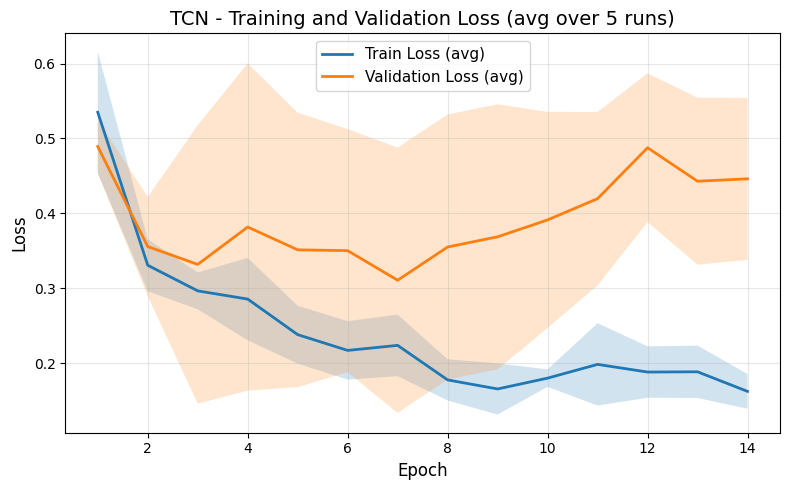

In [8]:
# Plot loss curves (averaged over 5 runs)
# Run the "Prepare Data and Train" cell (Section 3) first to define all_run_histories
if 'all_run_histories' not in globals() or not all_run_histories:
    if 'history' in globals() and history:
        print("Note: Using single-run history. Run the training cell (Section 3) first for 5-run average.")
        avg_train_loss = np.array(history['train_loss'])
        avg_val_loss = np.array(history['val_loss'])
        std_train_loss = np.zeros_like(avg_train_loss)
        std_val_loss = np.zeros_like(avg_val_loss)
        plot_title = 'TCN - Training and Validation Loss (single run)'
    else:
        raise NameError("Run the 'Prepare Data and Train' cell (Section 3) first to create all_run_histories.")
else:
    # Pad shorter runs with last value to handle different early-stopping epochs
    def pad_to_length(lst, length):
        if len(lst) >= length:
            return np.array(lst[:length])
        last = lst[-1] if lst else 0
        return np.array(lst + [last] * (length - len(lst)))
    max_epochs = max(len(h['train_loss']) for h in all_run_histories)
    train_losses = np.array([pad_to_length(h['train_loss'], max_epochs) for h in all_run_histories])
    val_losses = np.array([pad_to_length(h['val_loss'], max_epochs) for h in all_run_histories])
    avg_train_loss = np.mean(train_losses, axis=0)
    avg_val_loss = np.mean(val_losses, axis=0)
    std_train_loss = np.std(train_losses, axis=0)
    std_val_loss = np.std(val_losses, axis=0)
    plot_title = 'TCN - Training and Validation Loss (avg over 5 runs)'

plt.figure(figsize=(8, 5))
epochs = np.arange(1, len(avg_train_loss) + 1)
plt.plot(epochs, avg_train_loss, label='Train Loss (avg)', linewidth=2)
plt.fill_between(epochs, avg_train_loss - std_train_loss, avg_train_loss + std_train_loss, alpha=0.2)
plt.plot(epochs, avg_val_loss, label='Validation Loss (avg)', linewidth=2)
plt.fill_between(epochs, avg_val_loss - std_val_loss, avg_val_loss + std_val_loss, alpha=0.2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title(plot_title, fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

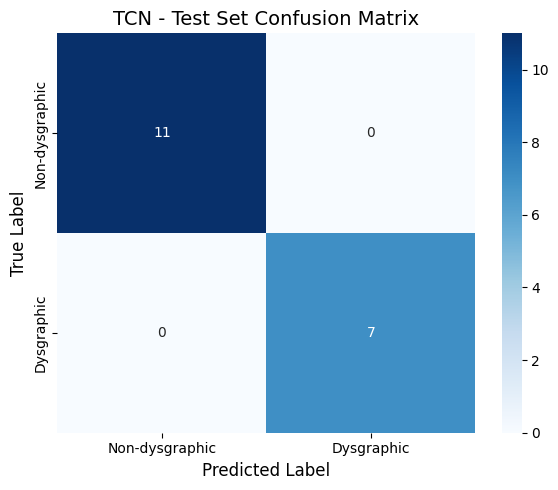

In [9]:
# Plot confusion matrix
# Auto-install seaborn if missing
try:
    import seaborn as sns
except ImportError:
    print("⚠ seaborn not found. Installing...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn", "--quiet"])
    import seaborn as sns
    print("✓ seaborn installed successfully!")

cm = test_metrics['confusion_matrix']
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-dysgraphic', 'Dysgraphic'],
            yticklabels=['Non-dysgraphic', 'Dysgraphic'])
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.title('TCN - Test Set Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Confusion matrix on ALL samples (full dataset — train + val + test)
# Uses the same scaler as training and the last run's `trained_model`.
trained_model.eval()
full_meta = meta_df.copy()
full_dataset = HandwritingDataset(
    full_meta, Config.DATA_ROOT, scaler, Config.MAX_LEN, Config.USE_DERIVATIVES
)
full_loader = DataLoader(full_dataset, batch_size=Config.BATCH_SIZE, shuffle=False)

all_probs_full, all_labels_full = [], []
with torch.no_grad():
    for batch in full_loader:
        x = batch["x"].to(Config.DEVICE)
        y = batch["y"].to(Config.DEVICE)
        lengths = batch["length"].to(Config.DEVICE)
        logits, _ = trained_model(x, lengths)
        probs = torch.softmax(logits, dim=1)[:, 1]
        all_probs_full.append(probs.cpu().numpy())
        all_labels_full.append(y.cpu().numpy())

all_probs_full = np.concatenate(all_probs_full)
all_labels_full = np.concatenate(all_labels_full)
full_metrics = compute_metrics(all_labels_full, all_probs_full)
cm_full = full_metrics["confusion_matrix"]
n_all = len(full_meta)

print(f"\nFull dataset ({n_all} samples):")
print(f"  Accuracy: {full_metrics['accuracy']:.4f}")
print(f"  Confusion matrix:\n{cm_full}")

try:
    import seaborn as sns
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn", "--quiet"])
    import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(cm_full, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-dysgraphic", "Dysgraphic"],
            yticklabels=["Non-dysgraphic", "Dysgraphic"])
plt.ylabel("True Label", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.title(f"TCN - Full Dataset Confusion Matrix (N={n_all})", fontsize=14)
plt.tight_layout()
plt.show()